Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

1. [0-1.5 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów SVC, zmieniając (uargumentuj wybór):
   1. funkcję jądra
   1. paramety jądra
   1. parametr `C`
1. [0-1 pkt] W przeszukaniu wyżej użyj [walidacji krzyżowej](https://scikit-learn.org/stable/modules/cross_validation.html) odpowiedniej dla zbioru niezbalansowanego
1. [0-1.5 pkt] Zbadaj zależność liczby wektorów nośnych per klasa. W tym celu wykorzystaj atrybuty `support_vectors_` i/lub `decision_function`. Czy istnieje korelacja między liczbą wektorów nośnych a dokładnością klasyfikatora?
2. [0-1 pkt] Podobnie jak w poprzednim zadaniu, zbadaj dokładność modelu w zależności od techniki skalowania oraz wyboru liczby cech
3. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyrysuj obszary decyzyjne. Weź pod uwagę, że implementacja w `scikit-learn`  działa na zasadzie OvR (*One-vs-Rest*) tzn. każdy klasyfikator uczy się oddzielnej hiperpowierzchni dla swojej klasy. Skomentuj wyniki
1. [0-1 pkt] Porównaj wyniki najlepszego modelu z `LinearSVC` z domyślnymi parametrami. Użyj MCC jako miary do porównania (uwzględnij odchylenie standardowe po podziałach w walidacji krzyżowej). Skomentuj wynik
1. [0-1 pkt] Czy w świetle uzyskanych wyników, SVC jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
1. [0-1.5 pkt] Zidentyfikuj używkę, z którą model radzi sobie najlepiej. Analiza nie musi być tak zaawansowana jak wyżej, ale powinna miarodajnie porównać wszystkie klasyfikatory między sobą. Efektywnie, chodzi o zaimplementowanie pętli po zmiennej `y` i odpowiednie dobranie parametrów w `GridSearchCV` oraz `Pipeline`
   
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

### Import i przygotowanie danych zgodnie z notebookiem z labów

In [1]:
!pip install ucimlrepo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from ucimlrepo import fetch_ucirepo
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, matthews_corrcoef, ConfusionMatrixDisplay

In [3]:
drugs = fetch_ucirepo(id=373)
X = drugs.data.features
y_all = drugs.data.targets
y = y_all.mushrooms

In [4]:
y_all['semer'].value_counts()

,count
semer,
CL0,1877
CL2,3
CL3,2
CL1,2
CL4,1


In [5]:
idx_to_drop = y_all[y_all['semer'] != 'CL0'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

In [6]:
y.value_counts()

,count
mushrooms,
CL0,982
CL3,272
CL2,259
CL1,208
CL4,114
CL5,39
CL6,3


In [7]:
idx_to_drop = y[y == 'CL6'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

In [8]:
label_encoder = LabelEncoder()
y_trans = label_encoder.fit_transform(y.values)

### train test split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y_trans,test_size=0.2,random_state=0)


### gridsearch parametrów svm

In [14]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = [
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 1]
    },
    {
        'kernel': ['poly'],
        'C': [0.1, 1, 10, 100],
        'degree': [2, 3],
        'gamma': ['scale', 'auto']
    },
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10]
    }
]

svc = SVC(random_state=0)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
grid_search = GridSearchCV(svc, param_grid, cv=skf, scoring='f1_macro',n_jobs=-1,verbose =1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 35 candidates, totalling 175 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=SVC(random_state=0), n_jobs=-1,
             param_grid=[{'C': [0.1, 1, 10, 100],
                          'gamma': ['scale', 'auto', 0.1, 1],
                          'kernel': ['rbf']},
                         {'C': [0.1, 1, 10, 100], 'degree': [2, 3],
                          'gamma': ['scale', 'auto'], 'kernel': ['poly']},
                         {'C': [0.1, 1, 10], 'kernel': ['linear']}],
             scoring='f1_macro', verbose=1)

Uzasadnienie wyboru parametrów:
- funkcje jądra:
  - linear - najprostsza funkcja jądrowa, dobra gdy jest niewiele cech. tworzy wielowymiarową plaszczyznę którą stara się podzielić dane na klasy.
  - poly - trochę bardziej skomplikowane niż linear, stara się oddzielić klasy za pomocą wielomianów.
  - rbf - najbardziej uniwersalny i najbardziej skomplikowany, tworzy takie "wysepki" które oddzielają klasy.

- parametry jądra:
  - gamma - określa jak daleko sięga wpływ pojedynczego przykładu w trening: auto - określa wartość jako 1/ (liczba cech), scaled uwzględnia jeszcze wariancję danych
  - degree - dla funkcji jądra poly, określa stopień wielomianu, który jest tam używany.

- parametr C - regularyzacja - małe wartości narzucają silną regularyzację, pozwalają na większy margines  i tolerancję na blędy, duże wartości starają się precyzyjnie określić podział klas, mniejszy margines i tolerancja na błędy. W ramach przeszukania gridsearch sprawdziłem wartości od bardzo małych 0.1 do dużych 100.

W GridSearch wykorzystałem walidację krzyżową. W przykładzie z zajęć został wykorzystany KFold, natomiast ze względu na niezbalansowanie zbioru wykorzstałem powyżej StratifiedKFold, która zachowuje oryginalne proporcje poszczególnych klas.

In [21]:
print("Najlepsze parametry: ", grid_search.best_params_)
print("Najlepsza wartość miary F1 w czasie treningu: ", grid_search.best_score_)

y_pred_test = grid_search.predict(X_test)
print(f"F1-macro na ostatecznym zbiorze testowym: {f1_score(y_test, y_pred_test, average='macro'):.4f}")

Najlepsze parametry:  {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Najlepsza wartość miary F1 w czasie treningu:  0.2849415215832344
F1-macro na ostatecznym zbiorze testowym: 0.2864


Jak można było przewidywać, patrząc na skomplikowanie datasetu, najlepiej poradził sobie `rbf` z hiperparametrem gamma ustawionym na `scaled`. Najlepsze C okazało się większe niż domyślna wartość 1, czyli zmniejszyć tolerancję na blędy.


Liczba wektorów nośnych: 1221

Analiza wektorów nośnych per klasa:


,Klasa,Próbki (Train),Wektory nośne,% wektorów nośnych,F1-score
0,CL0,787,520,66.07,0.897
1,CL1,174,171,98.28,0.801
2,CL2,215,214,99.53,0.768
3,CL3,205,198,96.59,0.792
4,CL4,86,86,100.00,0.768
5,CL5,32,32,100.00,0.638


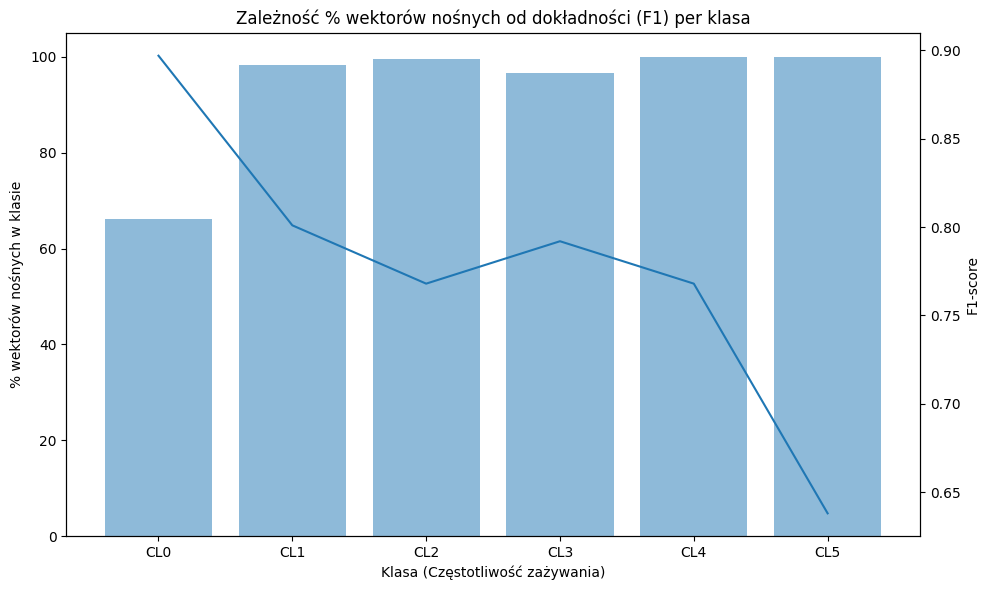

In [20]:
import matplotlib.pyplot as plt
import numpy as np

best_svc = grid_search.best_estimator_
svc_values = best_svc.support_vectors_
print(f"Liczba wektorów nośnych: {len(svc_values)}")
sv_indices = best_svc.support_

if isinstance(y_train, pd.Series):
    sv_classes = y_train.iloc[sv_indices].values
else:
    sv_classes = y_train[sv_indices]

sv_unique_classes, n_support_per_class = np.unique(sv_classes, return_counts=True)
unique_classes, counts_per_class = np.unique(y_train, return_counts=True)
support_ratio = (n_support_per_class / counts_per_class) * 100
y_pred_train = best_svc.predict(X_train)
f1_per_class = f1_score(y_train, y_pred_train, average=None)
class_names = label_encoder.inverse_transform(unique_classes)

df_support = pd.DataFrame({
    'Klasa': class_names,
    'Próbki (Train)': counts_per_class,
    'Wektory nośne': n_support_per_class,
    '% wektorów nośnych': support_ratio.round(2),
    'F1-score': f1_per_class.round(3)
})

print("\nAnaliza wektorów nośnych per klasa:")
display(df_support)

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Klasa (Częstotliwość zażywania)')
ax1.set_ylabel('% wektorów nośnych w klasie')
ax1.bar(class_names, df_support['% wektorów nośnych'], alpha=0.5, label='% Wektorów nośnych')

ax2 = ax1.twinx()
ax2.set_ylabel('F1-score')
ax2.plot(class_names, df_support['F1-score'], label='F1-score')

plt.title('Zależność % wektorów nośnych od dokładności (F1) per klasa')
fig.tight_layout()
plt.show()

Na wykresie możemy zobaczyć zależność odwrotną między liczbą wektorów nośnych a F1 score; im większy % wektorów nośnych w danej klasie, tym niższy wynik w metryce f1-score.
Najliczniejsza klasa CL0 ma najniższy % wektorów nośnych oraz najwyższy wynik f1 score. Dla rzadziej występujących klas CL1-CL5 % wektorów nośnych wynosi prawie 100. Na tej podstawie można stwierdzić, że model ma duży problem żeby dostosować ogólne reguły podziału klas i wpada w znaczny overfitting dopasowując się do każdego punktu.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif)),
    ('svm',SVC(kernel='rbf', C=10, gamma='scale', random_state=0))
])

param_grid_pipe = {
    'scaler': [StandardScaler(), MinMaxScaler(), RobustScaler()],
    'feature_selection__k': [2,4,6,8,10,'all'],
}

grid_search_pipe = GridSearchCV(pipeline, param_grid_pipe, cv=skf, scoring='f1_macro',n_jobs=-1,verbose =1)

grid_search_pipe.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=0, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('feature_selection', SelectKBest()),
                                       ('svm', SVC(C=10, random_state=0))]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [2, 4, 6, 8, 10, 'all'],
                         'scaler': [StandardScaler(), MinMaxScaler(),
                                    RobustScaler()]},
             scoring='f1_macro', verbose=1)

In [23]:
print("najlepszy pipeline: ", grid_search_pipe.best_params_)
print("Najlepsza wartość miary F1 w czasie treningu: ", grid_search_pipe.best_score_)

y_pred_test_pipe = grid_search_pipe.predict(X_test)
print(f"f1-macro na zbiorze testowym {f1_score(y_test, y_pred_test_pipe, average='macro')}")


najlepszy pipeline:  {'feature_selection__k': 'all', 'scaler': StandardScaler()}
Najlepsza wartość miary F1 w czasie treningu:  0.2893158875410279
f1-macro na zbiorze testowym 0.2830987282645871


Tabela zależności (F1-score) - Skaler vs Liczba cech:


param_feature_selection__k,2,4,6,8,10,all
scaler_name,,,,,,
StandardScaler(),0.257,0.264,0.266,0.277,0.269,0.289
MinMaxScaler(),0.264,0.280,0.256,0.262,0.260,0.271
RobustScaler(),0.258,0.263,0.273,0.276,0.272,0.274


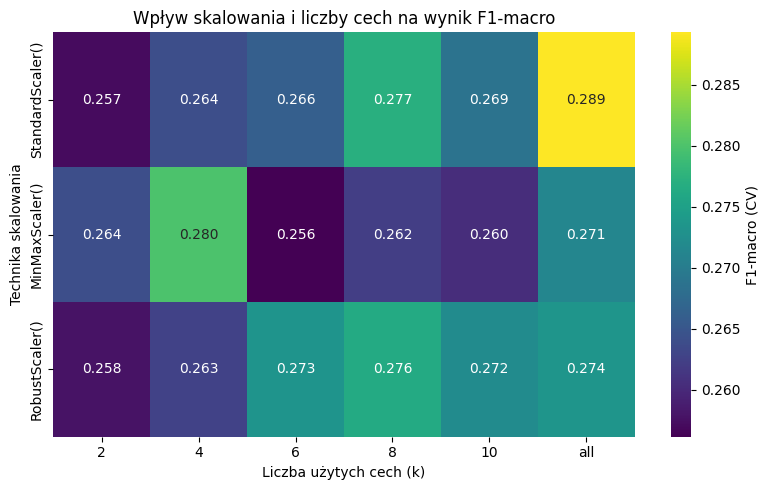

In [26]:
import seaborn as sns

results_df = pd.DataFrame(grid_search_pipe.cv_results_)

results_df['scaler_name'] = results_df['param_scaler']

pivot_table = results_df.pivot(
    index='scaler_name',
    columns='param_feature_selection__k',
    values='mean_test_score'
)

print("Tabela zależności (F1-score) - Skaler vs Liczba cech:")
display(pivot_table.round(3))

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".3f", cbar_kws={'label': 'F1-macro (CV)'})
plt.title('Wpływ skalowania i liczby cech na wynik F1-macro')
plt.xlabel('Liczba użytych cech (k)')
plt.ylabel('Technika skalowania')
plt.tight_layout()
plt.show()

Najlepsze wyniki zostały uzyskane za pomocą standard scalera oraz przy wykorzystaniu wszystkich cech.
Selekcja cech dała ciekawy rezultat dla minmax scalera, przy wyborze 4 cech. Wynik tej kombinacji został przekroczony dopiero po wykorzystaniu wszystkich cech oraz zmianie scalera.
Niezależnie jednak od liczby wybranych cech oraz wykorzystanego scalera, wynik dla metryki f1-score dalej nie przekracza 0.29, co może oznaczać, że dataset jest trudny dla tego modelu.